In [ ]:
!pip install dask[dataframe] polars psutil matplotlib pandas pyarrow

In [ ]:
import pandas as pd
import dask.dataframe as dd
import polars as pl

import time
import psutil
import os
import matplotlib.pyplot as plt

In [ ]:
file_path = "/content/cleaned_data.csv"

df_check = pd.read_csv(file_path)

print(df_check.shape)
print(df_check.columns)
df_check.head()

(147582, 13)
Index(['product_id', 'sku', 'title', 'author', 'publisher', 'current_price',
       'compare_price', 'discount_pct', 'grams', 'tags', 'image_url',
       'created_at', 'description'],
      dtype='object')


,product_id,sku,title,author,publisher,current_price,compare_price,discount_pct,grams,tags,image_url,created_at,description
0,6978035122382,9780751547238,Visions,Kelley Armstrong,Sphere,17.9,62.90,71.5,355,"[2022], BXOS, F CTM, Fiction, Kelley Armstrong...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:08+0800,"Olivia Jones is smart, capable, loyal...and th..."
1,6978035318990,9780751548174,The Bone Bed,Patricia Cornwell,Sphere,17.9,43.95,59.3,360,"[2022], BXOS, F CTM, Fiction, Paperback, Patri...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:08+0800,A woman has vanished while digging a dinosaur ...
2,6978035417294,9781447205180,Jasmine Skies,Sita Brahmachari,MacMillan Children's Books,12.9,32.95,60.8,340,"[2022], BXOS, F YA, Fiction, Paperback, RM 10 ...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:09+0800,Mira Levenson is bursting with excitement as s...
3,6978034794702,9780099461050,The Old Devils,Kingsley Amis,Vintage Publishing,17.9,59.94,70.1,310,"[2022], BXOS, F LIT, Fiction, Kingsley Amis, P...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:07+0800,"Malcolm, Peter and Charlie and their Soave-sod..."
4,6978035515598,9781473223288,PHILIP K. DICK'S ELECTRIC DREAMS: VOLUME 1,Philip K. Dick,Gollancz,17.9,53.94,66.8,230,"[2022], BXOS, F SFF, Fiction, Paperback, Phili...",https://cdn.shopify.com/s/files/1/0601/0883/29...,2022-04-01T10:46:09+0800,"Based on the stories contained in this volume,..."


In [ ]:
def benchmark(operation_name, library_name, func, total_rows):
    process = psutil.Process(os.getpid())

    memory_before = process.memory_info().rss / (1024 * 1024)
    cpu_before = psutil.cpu_percent(interval=None)

    start_time = time.perf_counter()

    result = func()

    end_time = time.perf_counter()

    cpu_after = psutil.cpu_percent(interval=1)
    memory_after = process.memory_info().rss / (1024 * 1024)

    execution_time = end_time - start_time
    memory_used = memory_after - memory_before
    throughput = total_rows / execution_time if execution_time > 0 else 0

    return {
        "operation": operation_name,
        "library": library_name,
        "execution_time_sec": execution_time,
        "cpu_usage_percent": cpu_after,
        "memory_used_mb": memory_used,
        "throughput_rows_per_sec": throughput
    }

In [ ]:
total_rows = len(pd.read_csv(file_path))
print("Total rows:", total_rows)

Total rows: 147582


In [ ]:
results = []

# 1. Load CSV
results.append(benchmark(
    "Load CSV",
    "Pandas",
    lambda: pd.read_csv(file_path),
    total_rows
))

pdf = pd.read_csv(file_path)

# 2. Filter deals
results.append(benchmark(
    "Filter High Discount Books",
    "Pandas",
    lambda: pdf[(pdf["discount_pct"] > 70) & (pdf["current_price"] < 20)],
    total_rows
))

# 3. GroupBy publisher
results.append(benchmark(
    "GroupBy Publisher Aggregation",
    "Pandas",
    lambda: pdf.groupby("publisher").agg({
        "current_price": "mean",
        "discount_pct": "mean",
        "title": "count"
    }),
    total_rows
))

# 4. String operation on tags
results.append(benchmark(
    "String Extract Price Tier",
    "Pandas",
    lambda: pdf["tags"].astype(str).str.extract(r'(RM[\d\s\-\.]+)'),
    total_rows
))

# 5. Derived column calculation
results.append(benchmark(
    "Calculate Savings",
    "Pandas",
    lambda: pdf.assign(
        savings_rm = pdf["compare_price"] - pdf["current_price"],
        savings_pct_check = ((pdf["compare_price"] - pdf["current_price"]) / pdf["compare_price"] * 100).round(1)
    ),
    total_rows
))

# 6. Sorting
results.append(benchmark(
    "Sort by Discount and Price",
    "Pandas",
    lambda: pdf.sort_values(["discount_pct", "current_price"], ascending=[False, True]),
    total_rows
))

# 7. Top authors by average discount
results.append(benchmark(
    "Top Authors by Average Discount",
    "Pandas",
    lambda: pdf.groupby("author")["discount_pct"].mean().sort_values(ascending=False).head(20),
    total_rows
))

# 8. Write CSV
results.append(benchmark(
    "Write Output CSV",
    "Pandas",
    lambda: pdf.to_csv("/content/pandas_output.csv", index=False),
    total_rows
))

In [ ]:
# 1. Load CSV
results.append(benchmark(
    "Load CSV",
    "Dask",
    lambda: dd.read_csv(file_path, dtype={'sku': 'object'}).compute(),
    total_rows
))

ddf = dd.read_csv(file_path, dtype={'sku': 'object'})

# 2. Filter deals
results.append(benchmark(
    "Filter High Discount Books",
    "Dask",
    lambda: ddf[(ddf["discount_pct"] > 70) & (ddf["current_price"] < 20)].compute(),
    total_rows
))

# 3. GroupBy publisher
results.append(benchmark(
    "GroupBy Publisher Aggregation",
    "Dask",
    lambda: ddf.groupby("publisher").agg({
        "current_price": "mean",
        "discount_pct": "mean",
        "title": "count"
    }).compute(),
    total_rows
))

# 4. String operation on tags
results.append(benchmark(
    "String Extract Price Tier",
    "Dask",
    lambda: ddf["tags"].astype(str).str.extract(r'(RM[\d\s\-\.]+)').compute(),
    total_rows
))

# 5. Derived column calculation
results.append(benchmark(
    "Calculate Savings",
    "Dask",
    lambda: ddf.assign(
        savings_rm = ddf["compare_price"] - ddf["current_price"],
        savings_pct_check = ((ddf["compare_price"] - ddf["current_price"]) / ddf["compare_price"] * 100).round(1)
    ).compute(),
    total_rows
))

# 6. Sorting
results.append(benchmark(
    "Sort by Discount and Price",
    "Dask",
    lambda: ddf.sort_values(["discount_pct", "current_price"], ascending=[False, True]).compute(),
    total_rows
))

# 7. Top authors by average discount
results.append(benchmark(
    "Top Authors by Average Discount",
    "Dask",
    lambda: ddf.groupby("author")["discount_pct"].mean().compute().sort_values(ascending=False).head(20),
    total_rows
))

# 8. Write CSV
results.append(benchmark(
    "Write Output CSV",
    "Dask",
    lambda: ddf.to_csv("/content/dask_output_*.csv", index=False),
    total_rows
))

In [ ]:
# 1. Load CSV
results.append(benchmark(
    "Load CSV",
    "Polars",
    lambda: pl.read_csv(file_path, schema_overrides={'sku': pl.Utf8}),
    total_rows
))

pldf = pl.read_csv(file_path, schema_overrides={'sku': pl.Utf8})

# 2. Filter deals
results.append(benchmark(
    "Filter High Discount Books",
    "Polars",
    lambda: pldf.filter(
        (pl.col("discount_pct") > 70) & (pl.col("current_price") < 20)
    ),
    total_rows
))

# 3. GroupBy publisher
results.append(benchmark(
    "GroupBy Publisher Aggregation",
    "Polars",
    lambda: pldf.group_by("publisher").agg([
        pl.col("current_price").mean().alias("avg_price"),
        pl.col("discount_pct").mean().alias("avg_discount"),
        pl.col("title").count().alias("title_count")
    ]),
    total_rows
))

# 4. String operation on tags
results.append(benchmark(
    "String Extract Price Tier",
    "Polars",
    lambda: pldf.select(
        pl.col("tags").cast(pl.Utf8).str.extract(r'(RM[\d\s\-\.] magnet:[-]+)')
    ),
    total_rows
))

# 5. Derived column calculation
results.append(benchmark(
    "Calculate Savings",
    "Polars",
    lambda: pldf.with_columns([
        (pl.col("compare_price") - pl.col("current_price")).alias("savings_rm"),
        (((pl.col("compare_price") - pl.col("current_price")) / pl.col("compare_price")) * 100).round(1).alias("savings_pct_check")
    ]),
    total_rows
))

# 6. Sorting
results.append(benchmark(
    "Sort by Discount and Price",
    "Polars",
    lambda: pldf.sort(["discount_pct", "current_price"], descending=[True, False]),
    total_rows
))

# 7. Top authors by average discount
results.append(benchmark(
    "Top Authors by Average Discount",
    "Polars",
    lambda: pldf.group_by("author").agg(
        pl.col("discount_pct").mean().alias("avg_discount")
    ).sort("avg_discount", descending=True).head(20),
    total_rows
))

# 8. Write CSV
results.append(benchmark(
    "Write Output CSV",
    "Polars",
    lambda: pldf.write_csv("/content/polars_output.csv"),
    total_rows
))

In [ ]:
results_df = pd.DataFrame(results)

results_df

,operation,library,execution_time_sec,cpu_usage_percent,memory_used_mb,throughput_rows_per_sec
0,Load CSV,Pandas,3.922116,1.5,103.066406,3.762816e+04
1,Filter High Discount Books,Pandas,0.029669,3.0,0.304688,4.974207e+06
2,GroupBy Publisher Aggregation,Pandas,0.051974,2.5,0.437500,2.839531e+06
3,String Extract Price Tier,Pandas,0.095955,10.1,5.339844,1.538041e+06
4,Calculate Savings,Pandas,0.028882,54.0,0.000000,5.109871e+06
5,Sort by Discount and Price,Pandas,0.097942,27.3,0.437500,1.506835e+06
6,Top Authors by Average Discount,Pandas,0.126276,2.5,0.000000,1.168727e+06
7,Write Output CSV,Pandas,6.325191,1.5,-0.082031,2.333242e+04
8,Load CSV,Dask,4.220044,2.0,389.324219,3.497167e+04
9,Filter High Discount Books,Dask,4.173325,56.6,118.960938,3.536317e+04


In [ ]:
results_df.to_csv("/content/performance_results.csv", index=False)

In [ ]:
from google.colab import files
files.download("/content/performance_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

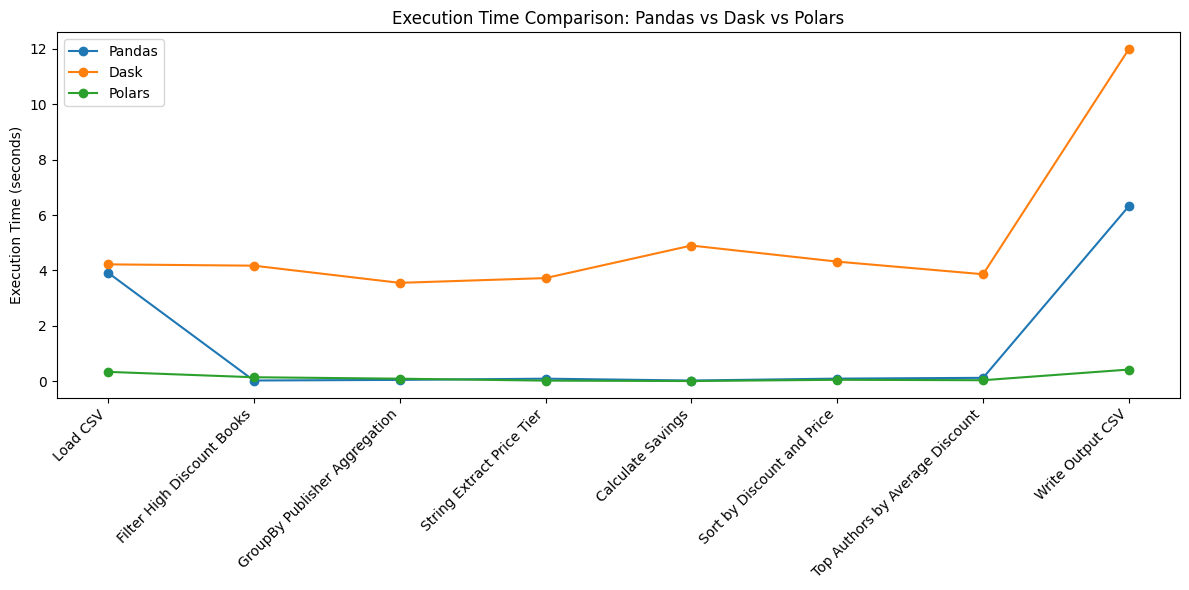

In [ ]:
plt.figure(figsize=(12,6))

for library in results_df["library"].unique():
    subset = results_df[results_df["library"] == library]
    plt.plot(subset["operation"], subset["execution_time_sec"], marker="o", label=library)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison: Pandas vs Dask vs Polars")
plt.legend()
plt.tight_layout()
plt.show()

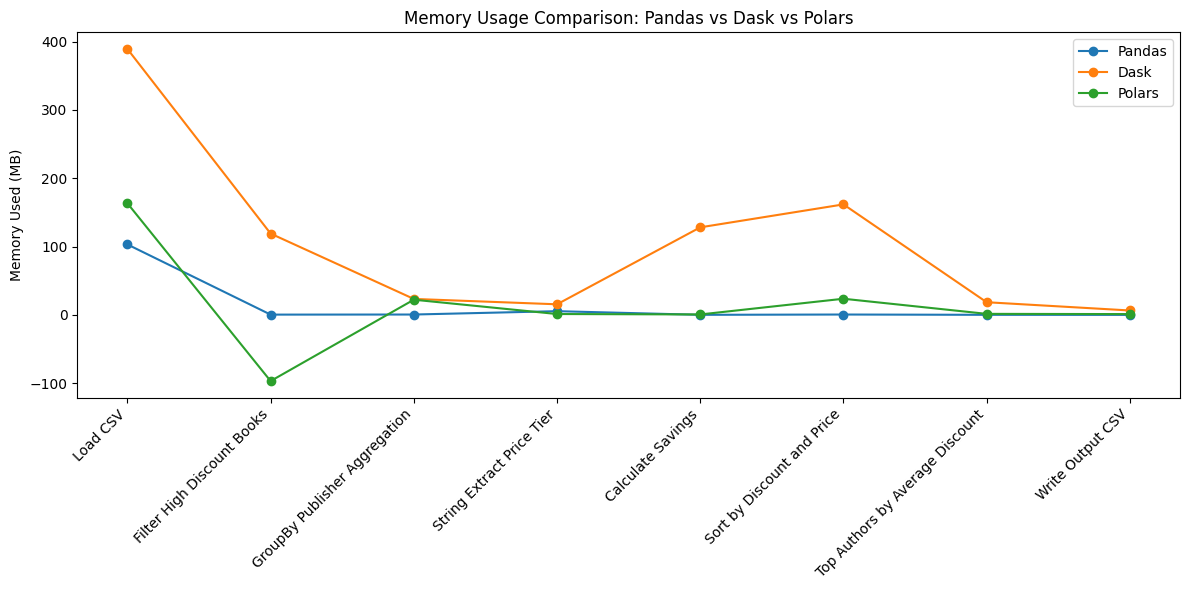

In [ ]:
plt.figure(figsize=(12,6))

for library in results_df["library"].unique():
    subset = results_df[results_df["library"] == library]
    plt.plot(subset["operation"], subset["memory_used_mb"], marker="o", label=library)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Memory Used (MB)")
plt.title("Memory Usage Comparison: Pandas vs Dask vs Polars")
plt.legend()
plt.tight_layout()
plt.show()

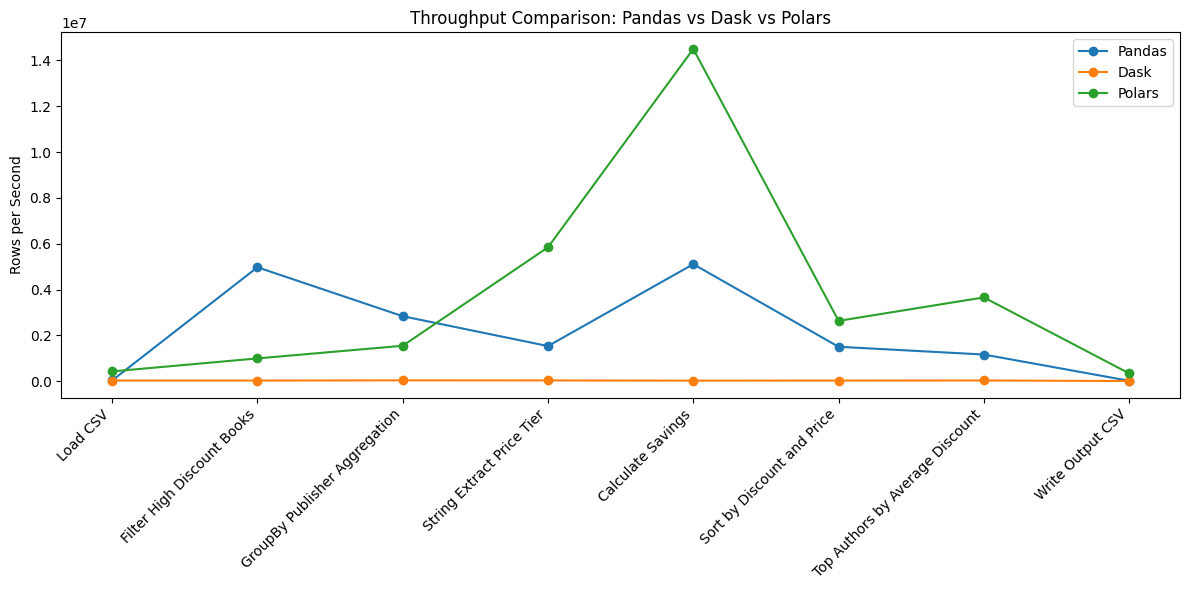

In [ ]:
plt.figure(figsize=(12,6))

for library in results_df["library"].unique():
    subset = results_df[results_df["library"] == library]
    plt.plot(subset["operation"], subset["throughput_rows_per_sec"], marker="o", label=library)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Rows per Second")
plt.title("Throughput Comparison: Pandas vs Dask vs Polars")
plt.legend()
plt.tight_layout()
plt.show()